# Projekt: Detekcja i OCR tablic rejestracyjnych (YOLO + EasyOCR)

**Cel:**
1) Wytrenować YOLO na zbiorze.
2) Zmierzyć IoU na losowych 30% zdjęć.
3) Dla wszystkich zdjęć: wykonać OCR wykrytych tablic i porównać z `annotations.xml`.
4) Dodać kod debugujący: co widzi OCR i co porównuje.

## 0. Instalacje i importy
Jeśli uruchamiasz pierwszy raz, odpal `pip` w pierwszej komórce.

In [58]:
# Jeśli uruchamiasz pierwszy raz:
# !pip install -U ultralytics opencv-python matplotlib numpy pandas tqdm easyocr lxml

import os, random, shutil, math
from pathlib import Path

import time

import numpy as np
import pandas as pd
from tqdm import tqdm

import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO
import easyocr
from lxml import etree

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("OK: importy")


OK: importy


## 1. Ścieżki do danych
Ustaw ścieżki do folderu ze zdjęciami i do `annotations.xml`.

In [2]:

PHOTOS_DIR = r"C:\Users\Dawid\Desktop\Informatyka 2025-27\Zaawansowane programowanie\photos"
ANNOTATIONS_XML = r"C:\Users\Dawid\Desktop\Informatyka 2025-27\Zaawansowane programowanie\annotations.xml"

assert os.path.isdir(PHOTOS_DIR), f"Nie widzę folderu: {PHOTOS_DIR}"
assert os.path.isfile(ANNOTATIONS_XML), f"Nie widzę pliku: {ANNOTATIONS_XML}"

print("PHOTOS_DIR:", PHOTOS_DIR)
print("ANNOTATIONS_XML:", ANNOTATIONS_XML)


PHOTOS_DIR: C:\Users\Dawid\Desktop\Informatyka 2025-27\Zaawansowane programowanie\photos
ANNOTATIONS_XML: C:\Users\Dawid\Desktop\Informatyka 2025-27\Zaawansowane programowanie\annotations.xml


## 2. Parsowanie `annotations.xml`
Budujemy DataFrame: `image_name, width, height, xtl, ytl, xbr, ybr, plate_text`.

Uwaga: XML może mieć `rotation`, ale YOLO (w standardzie) uczy bboxy osiowo wyrównane — **ignorujemy rotację**.

In [3]:
def parse_cvat_xml(xml_path: str, photos_dir: str) -> pd.DataFrame:
    tree = etree.parse(xml_path)
    root = tree.getroot()

    rows = []
    for img in root.findall("image"):
        name = img.get("name")
        width = int(float(img.get("width")))
        height = int(float(img.get("height")))

        for box in img.findall("box"):
            if box.get("label") != "plate":
                continue
            xtl = float(box.get("xtl"))
            ytl = float(box.get("ytl"))
            xbr = float(box.get("xbr"))
            ybr = float(box.get("ybr"))
            rotation = box.get("rotation")
            rotation = float(rotation) if rotation is not None else 0.0

            plate_text = ""
            for attr in box.findall("attribute"):
                if attr.get("name") == "plate number":
                    plate_text = (attr.text or "").strip()
                    break

            rows.append({
                "image_name": name,
                "width": width,
                "height": height,
                "xtl": xtl, "ytl": ytl, "xbr": xbr, "ybr": ybr,
                "rotation": rotation,
                "plate_text": plate_text
            })

    df = pd.DataFrame(rows)
    existing = set(os.listdir(photos_dir))
    df = df[df["image_name"].isin(existing)].reset_index(drop=True)
    return df

df = parse_cvat_xml(ANNOTATIONS_XML, PHOTOS_DIR)
display(df.head(10))
print("Liczba boxów:", len(df))
print("Liczba unikalnych zdjęć:", df["image_name"].nunique())


,image_name,width,height,xtl,ytl,xbr,ybr,rotation,plate_text
0,1.jpg,4640,2088,1318.15,537.20,2015.94,704.15,0.0,SCZ26114
1,10.jpg,4640,2088,2095.71,388.17,2523.81,498.64,0.0,SK404XK
2,100.jpg,2284,1522,1549.66,636.83,1771.85,699.78,0.0,SK321LE
3,101.jpg,2284,1522,1268.64,679.43,1631.55,790.41,3.7,STA0461C
4,102.jpg,2284,1522,1121.71,683.31,1419.82,772.10,2.9,SZA92043
5,103.jpg,2284,1522,1282.80,661.14,1601.27,744.55,2.9,SJZJN07
6,104.jpg,2284,1522,1619.65,657.40,1886.28,731.44,1.6,SJZJN07
7,105.jpg,2284,1522,1279.27,705.53,1610.71,811.11,3.9,SJ6479A
8,106.jpg,2284,1522,916.55,650.27,1236.93,759.01,4.8,SH9264A
9,107.jpg,2284,1524,1468.46,652.58,1837.38,754.50,2.5,SH4831C


Liczba boxów: 195
Liczba unikalnych zdjęć: 195


## 3. Konwersja do formatu YOLO
Tworzymy `dataset_yolo/` z podziałem 70/30 na train/val.

YOLO format etykiety: `class x_center y_center width height` w normalizacji 0..1.

In [ ]:
DATASET_DIR = Path("dataset_yolo")
IMAGES_TRAIN = DATASET_DIR / "images" / "train"
IMAGES_VAL   = DATASET_DIR / "images" / "val"
LABELS_TRAIN = DATASET_DIR / "labels" / "train"
LABELS_VAL   = DATASET_DIR / "labels" / "val"

for p in [IMAGES_TRAIN, IMAGES_VAL, LABELS_TRAIN, LABELS_VAL]:
    p.mkdir(parents=True, exist_ok=True)

grouped = df.groupby("image_name").apply(lambda g: g.to_dict("records")).to_dict()
all_images = sorted(grouped.keys())

random.shuffle(all_images)
split = int(0.7 * len(all_images))
train_imgs = set(all_images[:split])
val_imgs   = set(all_images[split:])

def clamp(v, lo, hi):
    return max(lo, min(hi, v))

def xyxy_to_yolo(xtl, ytl, xbr, ybr, w, h):
    xtl = clamp(xtl, 0, w-1)
    xbr = clamp(xbr, 0, w-1)
    ytl = clamp(ytl, 0, h-1)
    ybr = clamp(ybr, 0, h-1)
    bw = xbr - xtl
    bh = ybr - ytl
    xc = xtl + bw / 2
    yc = ytl + bh / 2
    return xc / w, yc / h, bw / w, bh / h

def write_label_file(records, out_txt: Path):
    lines = []
    for r in records:
        x, y, w, h = xyxy_to_yolo(r["xtl"], r["ytl"], r["xbr"], r["ybr"], r["width"], r["height"])
        lines.append(f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}")
    out_txt.write_text("\n".join(lines), encoding="utf-8")

def copy_and_label(img_name: str, split_name: str):
    src = Path(PHOTOS_DIR) / img_name
    if split_name == "train":
        dst_img = IMAGES_TRAIN / img_name
        dst_lbl = LABELS_TRAIN / (Path(img_name).stem + ".txt")
    else:
        dst_img = IMAGES_VAL / img_name
        dst_lbl = LABELS_VAL / (Path(img_name).stem + ".txt")

    shutil.copy2(src, dst_img)
    write_label_file(grouped[img_name], dst_lbl)

for img in tqdm(train_imgs, desc="copy train"):
    copy_and_label(img, "train")
for img in tqdm(val_imgs, desc="copy val"):
    copy_and_label(img, "val")

data_yaml = DATASET_DIR / "data.yaml"
yaml_text = (
    f"path: {DATASET_DIR.resolve()}\n"
    "train: images/train\n"
    "val: images/val\n\n"
    "names:\n"
    "  0: plate\n"
)
data_yaml.write_text(yaml_text, encoding="utf-8")

print("Gotowe:", DATASET_DIR.resolve())
print("Train:", len(train_imgs), "Val:", len(val_imgs))
print("data.yaml:", data_yaml)


C:\Users\Dawid\AppData\Local\Temp\ipykernel_34648\3990085671.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df.groupby("image_name").apply(lambda g: g.to_dict("records")).to_dict()
copy val: 100%|██████████| 59/59 [00:00<00:00, 178.97it/s]

Gotowe: C:\Users\Dawid\Desktop\Informatyka 2025-27\Zaawansowane programowanie\dataset_yolo
Train: 136 Val: 59
data.yaml: dataset_yolo\data.yaml


## 4. Kontrola wizualna adnotacji
Losujemy kilka obrazków i rysujemy bboxy z XML.

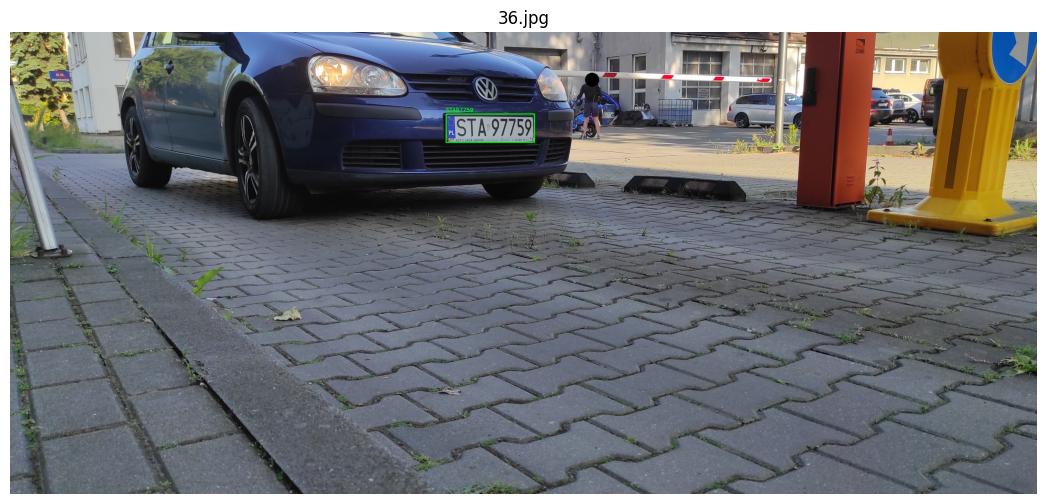

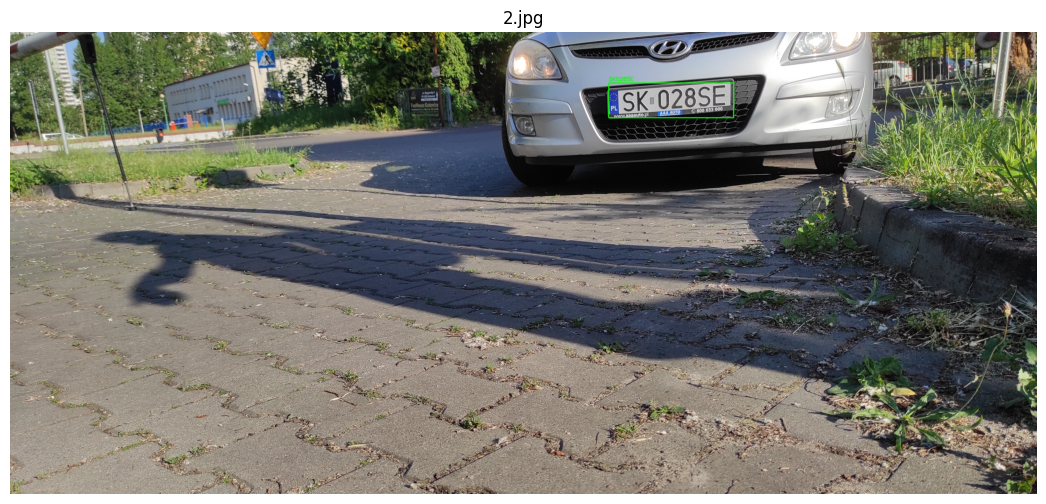

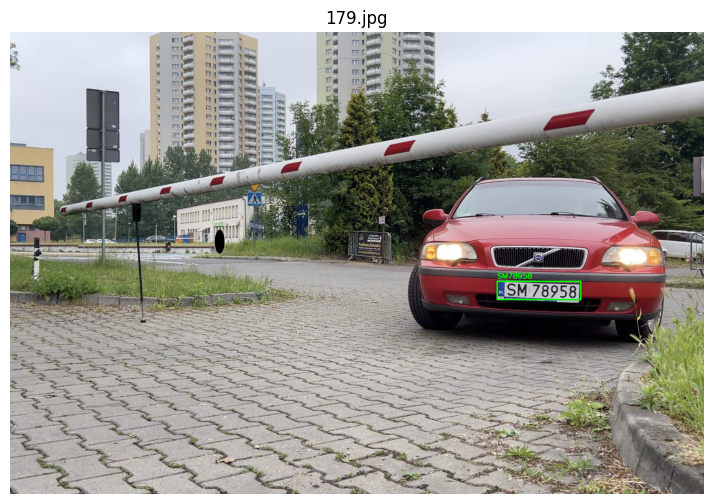

In [5]:
def draw_xyxy(img_rgb, xyxy, color=(0,255,0), thickness=2, label=None):
    x1,y1,x2,y2 = map(int, xyxy)
    cv2.rectangle(img_rgb, (x1,y1), (x2,y2), color, thickness)
    if label:
        cv2.putText(img_rgb, label, (x1, max(0,y1-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

def show_random_annot(n=3):
    samples = random.sample(all_images, k=min(n, len(all_images)))
    for name in samples:
        img = cv2.imread(str(Path(PHOTOS_DIR)/name))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        for r in grouped[name]:
            draw_xyxy(img_rgb, (r["xtl"], r["ytl"], r["xbr"], r["ybr"]), color=(0,255,0), thickness=3, label=r["plate_text"])
        plt.figure(figsize=(14,6))
        plt.title(name)
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.show()

show_random_annot(3)


## 5. Trening YOLO (Ultralytics YOLOv8)
Startujemy od `yolov8n.pt`. Jeśli masz mocniejsze GPU, możesz użyć `yolov8s.pt`.

Po treningu najlepsze wagi będą w `runs_plate/yolo_plate/weights/best.pt`.

In [6]:
BASE_MODEL = "yolov8n.pt"   # lub "yolov8s.pt"
EPOCHS = 25
IMG_SIZE = 960
BATCH = 4

model = YOLO(BASE_MODEL)

results = model.train(
    data=str(DATASET_DIR/"data.yaml"),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=0,          # ustaw "cpu" jeśli nie masz GPU
    workers=4,
    patience=15,
    project="runs_plate",
    name="yolo_plate",
    exist_ok=True
)

print("Trening zakończony.")
print("Wagi:", "runs_plate/yolo_plate/weights/best.pt")


New https://pypi.org/project/ultralytics/8.4.0 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.243  Python-3.11.6 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_yolo\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_plate, nbs=64, nms=

## 6. IoU na losowych 30% zdjęć
Dla losowych 30% obrazów liczmy IoU predykcji YOLO vs GT.
Dla każdego GT wybieramy pred o największym IoU (greedy).

In [7]:
from dataclasses import dataclass

@dataclass
class Box:
    x1: float; y1: float; x2: float; y2: float

def iou(a: Box, b: Box) -> float:
    ix1 = max(a.x1, b.x1)
    iy1 = max(a.y1, b.y1)
    ix2 = min(a.x2, b.x2)
    iy2 = min(a.y2, b.y2)
    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, a.x2-a.x1) * max(0.0, a.y2-a.y1)
    area_b = max(0.0, b.x2-b.x1) * max(0.0, b.y2-b.y1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

BEST_WEIGHTS = "runs_plate/yolo_plate/weights/best.pt"
assert os.path.isfile(BEST_WEIGHTS), "Nie widzę best.pt — upewnij się, że trening się zakończył."

detector = YOLO(BEST_WEIGHTS)

N = len(all_images)
k = max(1, int(0.30 * N))
eval_imgs = random.sample(all_images, k=k)

CONF = 0.25

ious = []
details = []

for name in tqdm(eval_imgs, desc="IoU eval"):
    img_path = str(Path(PHOTOS_DIR)/name)
    gt_boxes = [Box(r["xtl"], r["ytl"], r["xbr"], r["ybr"]) for r in grouped[name]]

    pred = detector.predict(img_path, conf=CONF, verbose=False)[0]
    pred_boxes = []
    if pred.boxes is not None and len(pred.boxes) > 0:
        for b in pred.boxes.xyxy.cpu().numpy():
            pred_boxes.append(Box(float(b[0]), float(b[1]), float(b[2]), float(b[3])))

    for gi, gt in enumerate(gt_boxes):
        best = 0.0
        best_idx = None
        for pi, pb in enumerate(pred_boxes):
            sc = iou(gt, pb)
            if sc > best:
                best = sc
                best_idx = pi
        ious.append(best)
        details.append({"image": name, "gt_index": gi, "best_iou": best, "num_preds": len(pred_boxes), "best_pred_index": best_idx})

ious = np.array(ious, dtype=float)
print(f"Średnie IoU: {ious.mean():.4f}")
print(f"Mediana IoU: {np.median(ious):.4f}")
print(f"% IoU > 0.50: {(ious>0.5).mean()*100:.2f}%")
print(f"% IoU > 0.75: {(ious>0.75).mean()*100:.2f}%")

df_iou = pd.DataFrame(details).sort_values("best_iou")
display(df_iou.head(10))


IoU eval: 100%|██████████| 58/58 [00:05<00:00,  9.69it/s]

Średnie IoU: 0.8944
Mediana IoU: 0.8935
% IoU > 0.50: 100.00%
% IoU > 0.75: 100.00%


,image,gt_index,best_iou,num_preds,best_pred_index
30,70.jpg,0,0.807388,1,0
0,13.jpg,0,0.810527,1,0
27,10.jpg,0,0.815718,1,0
10,116.jpg,0,0.818251,1,0
45,18.jpg,0,0.824510,1,0
50,143(1).jpg,0,0.826202,1,0
40,141.jpg,0,0.831715,1,0
35,181.jpg,0,0.834712,1,0
36,80.jpg,0,0.848956,1,0
9,134.jpg,0,0.853505,2,0


## 7. OCR (EasyOCR) dla wszystkich zdjęć + porównanie z GT
Normalizacja: tylko znaki `A-Z` i cyfry, wielkie litery.

Metryki: exact match, odległość Levenshteina, char accuracy.

In [69]:
import re
import cv2
import numpy as np

def crop_to_white_plate_area(bin_img, pad=6):
    # bin_img: uint8, 0/255
    if len(bin_img.shape) == 3:
        bin_img = cv2.cvtColor(bin_img, cv2.COLOR_BGR2GRAY)

    # 1) Upewnij się, że tło jest białe
    # (jeśli masz odwrotnie, odwróć)
    # Heurystyka: jeśli średnia jest niska, to prawdopodobnie tło jest czarne
    if bin_img.mean() < 127:
        bin_img = 255 - bin_img

    # 2) Maskujemy białe tło
    white = (bin_img > 0).astype(np.uint8) * 255

    # 3) Morfologia: sklej tło w jedną bryłę mimo przerw / ramek
    h, w = white.shape
    kx = max(3, w // 30)   # zależne od rozmiaru
    ky = max(3, h // 10)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kx, ky))
    white_closed = cv2.morphologyEx(white, cv2.MORPH_CLOSE, kernel, iterations=1)

    # 4) Największy kontur = główna "biała wyspa"
    cnts, _ = cv2.findContours(white_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return bin_img  # fallback

    c = max(cnts, key=cv2.contourArea)
    x, y, ww, hh = cv2.boundingRect(c)

    # 5) Dodaj margines, żeby nie uciąć znaków
    x2 = max(0, x - pad)
    y2 = max(0, y - pad)
    x3 = min(w, x + ww + pad)
    y3 = min(h, y + hh + pad)

    return bin_img[y2:y3, x2:x3]


ALLOWED = re.compile(r"[A-Z0-9]")

def normalize_plate(s: str) -> str:
    if s is None:
        return ""

    s = s.upper()

    # 1) Zamiany "śmieci OCR" zanim odfiltrujemy znaki
    # (te znaki i tak nie przejdą regexa, więc trzeba je poprawić wcześniej)
    pre_map = {
        "|": "I",
        "%": "9",
        "$": "J"
    }
    for k, v in pre_map.items():
        s = s.replace(k, v)

    # 2) Zostaw tylko A-Z i 0-9
    s = "".join(ALLOWED.findall(s))

    if not s:
        return ""

    # 3) Wymuś: pierwsze 2 znaki to litery
    # mapowanie cyfr -> liter (typowe pomyłki OCR)
    digit_to_letter = {
        "0": "O",
        "1": "I",
        "2": "Z",
        "5": "S",
        "6": "G",
        "8": "B",
        "4": "A",  # bywa kontrowersyjne, ale czasem pomaga
        "7": "T",  # czasem
        "9": "G",  # czasem (rzadziej)
    }

    chars = list(s)
    for i in range(min(2, len(chars))):
        if chars[i].isdigit():
            chars[i] = digit_to_letter.get(chars[i], chars[i])

    s = "".join(chars)

    # 4) Jeśli > 8 znaków, usuń ostatnie znaki aż będzie <= 8
    while len(s) > 8:
        s = s[:-1]

    return s



def levenshtein(a: str, b: str) -> int:
    a = a or ""
    b = b or ""
    n, m = len(a), len(b)
    dp = list(range(m+1))
    for i in range(1, n+1):
        prev = dp[0]
        dp[0] = i
        for j in range(1, m+1):
            cur = dp[j]
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[j] = min(dp[j] + 1, dp[j-1] + 1, prev + cost)
            prev = cur
    return dp[m]

def char_accuracy(a: str, b: str) -> float:
    denom = max(len(a or ""), len(b or ""), 1)
    return 1.0 - (levenshtein(a, b) / denom)

def calculate_final_grade(accuracy_percent: float, processing_time_sec: float) -> float:
    """
    Calculates the final grade based on license plate OCR accuracy and processing time.

    Parameters:
    - accuracy_percent: OCR accuracy as a percentage (0–100)
    - processing_time_sec: total time to process 100 images in seconds

    Returns:
    - Grade on a scale from 2.0 to 5.0 (rounded to the nearest 0.5)
    """

    # Minimum requirements
    if accuracy_percent < 60 or processing_time_sec > 60:
        return 2.0

    # Normalize accuracy: 60% → 0.0, 100% → 1.0
    accuracy_norm = (accuracy_percent - 60.0) / 40.0

    # Normalize time: 60s → 0.0, 10s → 1.0
    time_norm = (60.0 - processing_time_sec) / 50.0
    time_norm = max(0.0, min(1.0, time_norm))  # safety clamp

    # Weighted score
    score = 0.7 * accuracy_norm + 0.3 * time_norm

    # Final grade: 2.0 → 5.0
    grade = 2.0 + 3.0 * score

    # Round to nearest 0.5
    return round(grade * 2) / 2



reader = easyocr.Reader(['en'], gpu=True)  # ustaw gpu=False jeśli trzeba

PADDING = 8
CONF_OCR = 0.25

def crop_with_padding(img_bgr, box: Box, padding=PADDING):
    h, w = img_bgr.shape[:2]
    x1 = int(clamp(box.x1 - padding, 0, w-1))
    y1 = int(clamp(box.y1 - padding, 0, h-1))
    x2 = int(clamp(box.x2 + padding, 0, w-1))
    y2 = int(clamp(box.y2 + padding, 0, h-1))
    return img_bgr[y1:y2, x1:x2].copy(), (x1, y1, x2, y2)

# =========================
# OCR – wersja "produkcyjna"
# =========================
PLATE_TEXT_RATIO = 0.82   # bierzemy tylko górne 65% tablicy
OCR_Y_FILTER = 0.60       # filtr bboxów OCR (Y) - odrzuca niskie napisy
OCR_MIN_CONF = 0.35       # minimalna pewność OCR fragmentu

def preprocess_plate(crop_bgr):
    """Grayscale + resize + OTSU"""
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th = crop_to_white_plate_area(th, pad=6)

    # (opcjonalnie) lekkie czyszczenie po cropie
    th = cv2.medianBlur(th, 3)
    return th

def cut_only_plate_text(crop_bgr, ratio=PLATE_TEXT_RATIO):
    """Odcina dół cropa (reklamy, ramki, itp.)"""
    h, w = crop_bgr.shape[:2]
    return crop_bgr[:max(1, int(h * ratio)), :]

def run_ocr_on_crop(crop_bgr):
    """
    OCR z:
    - odcięciem dołu tablicy
    - preprocessingiem
    - filtrowaniem bboxów po Y i confidence
    """
    crop_bgr = cut_only_plate_text(crop_bgr, PLATE_TEXT_RATIO)
    prep = preprocess_plate(crop_bgr)

    # EasyOCR przyjmuje też obrazy 2D (grayscale/binary), więc OK
    results = reader.readtext(prep, detail=1)

    h = prep.shape[0]
    kept = []
    kept_confs = []

    for bbox, text, conf in results:
        conf = float(conf)
        if conf < OCR_MIN_CONF:
            continue

        # bbox = 4 punkty; bierzemy środek w osi Y
        ys = [p[1] for p in bbox]
        y_center = sum(ys) / len(ys)

        # zostaw tylko górną część tablicy
        if y_center < h * OCR_Y_FILTER:
            kept.append(text)
            kept_confs.append(conf)

    joined = "".join(kept)
    mean_conf = float(np.mean(kept_confs)) if kept_confs else 0.0
    return results, joined, mean_conf

# =========================
# Pętla: YOLO -> crop -> OCR -> porównanie
# =========================
records = []

all_images = sorted([
    p.name for p in Path(r"C:\Users\Dawid\Desktop\Informatyka 2025-27\Zaawansowane programowanie\phottos").iterdir() # to jest to samo co PHOTOS_DIR
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
])[:100]

t0 = time.time()
for name in tqdm(all_images, desc="YOLO + OCR"):
    img_path = str(Path(r"C:\Users\Dawid\Desktop\Informatyka 2025-27\Zaawansowane programowanie\phottos") / name) # to jest to samo co PHOTOS_DIR
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        continue

    gt_texts = [normalize_plate(r["plate_text"]) for r in grouped[name]]
    gt_main = gt_texts[0] if gt_texts else ""

    pred = detector.predict(img_path, conf=CONF_OCR, verbose=False)[0]
    pred_boxes = []
    pred_confs = []
    if pred.boxes is not None and len(pred.boxes) > 0:
        for b, c in zip(pred.boxes.xyxy.cpu().numpy(), pred.boxes.conf.cpu().numpy()):
            pred_boxes.append(Box(float(b[0]), float(b[1]), float(b[2]), float(b[3])))
            pred_confs.append(float(c))

    # wybór: największy box (zwykle tablica)
    best_box = None
    best_area = -1
    best_conf = None
    for b, c in zip(pred_boxes, pred_confs):
        area = (b.x2 - b.x1) * (b.y2 - b.y1)
        if area > best_area:
            best_area = area
            best_box = b
            best_conf = c

    if best_box is None:
        records.append({
            "image": name, "gt": gt_main,
            "ocr_raw": "", "ocr_norm": "", "ocr_conf": 0.0,
            "exact": False, "edit_dist": None, "char_acc": 0.0,
            "status": "NO_DETECTION"
        })
        continue

    crop, crop_xyxy = crop_with_padding(img_bgr, best_box, padding=PADDING)
    ocr_details, ocr_joined, ocr_conf = run_ocr_on_crop(crop)
    ocr_norm = normalize_plate(ocr_joined)

    dist = levenshtein(gt_main, ocr_norm)
    acc = char_accuracy(gt_main, ocr_norm)

    records.append({
        "image": name, "gt": gt_main,
        "ocr_raw": ocr_joined, "ocr_norm": ocr_norm, "ocr_conf": ocr_conf,
        "exact": (gt_main == ocr_norm), "edit_dist": dist, "char_acc": acc,
        "det_conf": best_conf,
        "status": "OK"
    })    
processing_time_sec = time.time() - t0

df_ocr = pd.DataFrame(records)
display(df_ocr.head(3))

ok = df_ocr[df_ocr["status"] == "OK"]
exact_acc = float(ok["exact"].mean() * 100)

# print("=== Wyniki OCR ===")
# print("Liczba obrazków:", len(df_ocr))
# print("Brak detekcji:", int((df_ocr["status"] == "NO_DETECTION").sum()))
# print("Exact match (na tych z detekcją):", round(float(ok["exact"].mean() * 100), 2), "%")
# print("Średnia char_acc (na tych z detekcją):", round(float(ok["char_acc"].mean()), 4))
# print("Mediana char_acc (na tych z detekcją):", round(float(ok["char_acc"].median()), 4))

final_grade = calculate_final_grade(
    accuracy_percent=exact_acc,
    processing_time_sec=processing_time_sec
)

print("=== Ocena końcowa projektu ===")
print(f"Dokładność OCR: {exact_acc:.2f} %")
print(f"Czas przetwarzania 100 obrazów: {processing_time_sec:.2f} s")
print(f"Ocena końcowa: {final_grade}")


YOLO + OCR: 100%|██████████| 100/100 [00:26<00:00,  3.77it/s]


,image,gt,ocr_raw,ocr_norm,ocr_conf,exact,edit_dist,char_acc,det_conf,status
0,1.jpg,SCZ26114,SCZ 26114,SCZ26114,0.881202,True,0,1.0,0.979539,OK
1,10.jpg,SK404XK,SK 404XK,SK404XK,0.496013,True,0,1.0,0.791126,OK
2,105.jpg,SJ6479A,SJ6479A,SJ6479A,0.717587,True,0,1.0,0.965635,OK


=== Ocena końcowa projektu ===
Dokładność OCR: 82.00 %
Czas przetwarzania 100 obrazów: 26.53 s
Ocena końcowa: 4.0


## 8. Debug: co widzi OCR i co porównuje
Pokazuje obraz z GT (zielony) i pred (czerwony), crop, surowe wyniki OCR oraz porównanie po normalizacji.

In [ ]:
# %matplotlib inline

# def debug_one(image_name: str, conf=0.25, padding=8):
#     img_path = str(Path(PHOTOS_DIR) / image_name)
#     img_bgr = cv2.imread(img_path)
#     if img_bgr is None:
#         print("Nie mogę wczytać:", img_path)
#         return

#     # --- GT ---
#     gt_recs = grouped.get(image_name, [])
#     gt_boxes = [Box(r["xtl"], r["ytl"], r["xbr"], r["ybr"]) for r in gt_recs]
#     gt_texts = [normalize_plate(r["plate_text"]) for r in gt_recs]
#     gt_main = gt_texts[0] if gt_texts else ""

#     # --- YOLO pred ---
#     pred = detector.predict(img_path, conf=conf, verbose=False)[0]
#     pred_boxes = []
#     pred_confs = []
#     if pred.boxes is not None and len(pred.boxes) > 0:
#         for b, c in zip(pred.boxes.xyxy.cpu().numpy(), pred.boxes.conf.cpu().numpy()):
#             pred_boxes.append(Box(float(b[0]), float(b[1]), float(b[2]), float(b[3])))
#             pred_confs.append(float(c))

#     # wybierz największy box
#     best_box = None
#     best_idx = None
#     best_area = -1
#     for i, b in enumerate(pred_boxes):
#         area = (b.x2 - b.x1) * (b.y2 - b.y1)
#         if area > best_area:
#             best_area = area
#             best_box = b
#             best_idx = i

#     # --- Wizualizacja: GT vs Pred ---
#     vis = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
#     for i, gt in enumerate(gt_boxes):
#         draw_xyxy(vis, (gt.x1, gt.y1, gt.x2, gt.y2),
#                   color=(0, 255, 0), thickness=3, label=f"GT:{gt_texts[i]}")
#     if best_box is not None:
#         draw_xyxy(vis, (best_box.x1, best_box.y1, best_box.x2, best_box.y2),
#                   color=(255, 0, 0), thickness=3, label=f"PRED conf={pred_confs[best_idx]:.2f}")

#     plt.figure(figsize=(14, 6))
#     plt.title(f"{image_name} | GT zielony, PRED czerwony")
#     plt.imshow(vis)
#     plt.axis("off")
#     plt.show()

#     if best_box is None:
#         print("Brak detekcji YOLO.")
#         return

#     # --- CROP ---
#     crop, crop_xyxy = crop_with_padding(img_bgr, best_box, padding=padding)

#     plt.figure(figsize=(10, 3))
#     plt.title(f"CROP surowy (padding={padding})")
#     plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
#     plt.axis("off")
#     plt.show()

#     # --- Co dokładnie trafia do OCR w wersji 'produkcyjnej' ---
#     # (kopiujemy logikę z run_ocr_on_crop, ale z debug-printami)
#     crop_cut = cut_only_plate_text(crop, PLATE_TEXT_RATIO)

#     plt.figure(figsize=(10, 3))
#     plt.title(f"CROP po odcięciu dołu (ratio={PLATE_TEXT_RATIO})")
#     plt.imshow(cv2.cvtColor(crop_cut, cv2.COLOR_BGR2RGB))
#     plt.axis("off")
#     plt.show()

#     prep = preprocess_plate(crop_cut)

#     plt.figure(figsize=(10, 3))
#     plt.title("Preprocessing (grayscale+resize+OTSU) - to widzi OCR")
#     plt.imshow(prep, cmap="gray")
#     plt.axis("off")
#     plt.show()

#     # OCR na preprocessed
#     ocr_details = reader.readtext(prep, detail=1)

#     # Filtr jak w run_ocr_on_crop
#     h = prep.shape[0]
#     kept_texts = []
#     kept_confs = []

#     print("=== OCR surowe wyniki + decyzja filtra ===")
#     for bbox, text, conf_ in ocr_details:
#         conf_ = float(conf_)
#         ys = [p[1] for p in bbox]
#         y_center = sum(ys) / len(ys)

#         reasons = []
#         if conf_ < OCR_MIN_CONF:
#             reasons.append(f"conf<{OCR_MIN_CONF}")
#         if y_center >= h * OCR_Y_FILTER:
#             reasons.append(f"y>={OCR_Y_FILTER}h")

#         status = "KEEP" if not reasons else "DROP (" + ", ".join(reasons) + ")"
#         print(f"- text='{text}' conf={conf_:.3f} y_center={y_center:.1f}/{h} -> {status}")

#         if not reasons:
#             kept_texts.append(text)
#             kept_confs.append(conf_)

#     ocr_joined = "".join(kept_texts)
#     ocr_conf = float(np.mean(kept_confs)) if kept_confs else 0.0

#     # Normalizacja i metryki
#     ocr_norm = normalize_plate(ocr_joined)

#     print("\n=== Normalizacja i porównanie ===")
#     print("GT      :", gt_main)
#     print("OCR_RAW :", ocr_joined)
#     print("OCR_NORM:", ocr_norm)
#     print("OCR_conf(mean):", round(ocr_conf, 3))
#     print("EDIT DIST:", levenshtein(gt_main, ocr_norm))
#     print("CHAR ACC :", round(char_accuracy(gt_main, ocr_norm), 4))


,image,gt,ocr_norm,char_acc,edit_dist,ocr_conf,det_conf
1,137.jpg,ST6666U,,0.0,7,0.0,0.905274
4,5.jpg,SRB9NP9,,0.0,7,0.0,0.965883
6,169.jpg,STAGA81,,0.0,7,0.0,0.835782
9,160.jpg,SC3222P,,0.0,7,0.0,0.923253
12,126.jpg,SJ7749E,,0.0,7,0.0,0.938018
13,99.jpg,CB441ML,,0.0,7,0.0,0.984867
15,112.jpg,SH9337C,,0.0,7,0.0,0.934491
17,131.jpg,SL98181,,0.0,7,0.0,0.947572
26,132.jpg,SMY01258,,0.0,8,0.0,0.961233
31,158.jpg,SH9435C,,0.0,7,0.0,0.939506


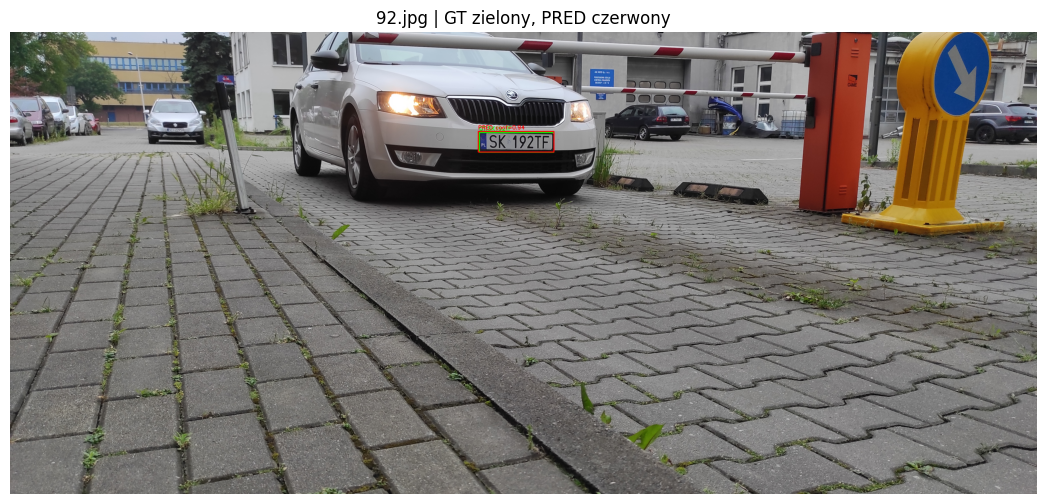

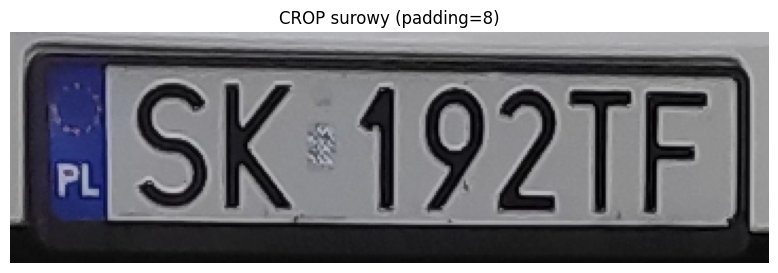

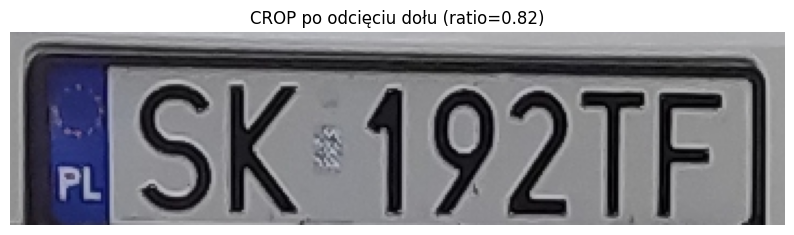

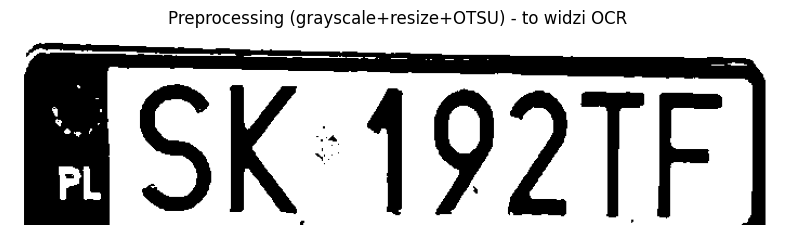

=== OCR surowe wyniki + decyzja filtra ===
- text='PL' conf=0.973 y_center=139.0/178 -> DROP (y>=0.6h)
- text='SK 192TF' conf=0.918 y_center=107.0/178 -> DROP (y>=0.6h)

=== Normalizacja i porównanie ===
GT      : SK192TF
OCR_RAW : 
OCR_NORM: 
OCR_conf(mean): 0.0
EDIT DIST: 7
CHAR ACC : 0.0


In [ ]:
# worst = df_ocr[df_ocr["status"]=="OK"].sort_values("char_acc").head(20)
# display(worst[["image","gt","ocr_norm","char_acc","edit_dist","ocr_conf","det_conf"]])

# debug_one(worst.iloc[12]["image"])
